
# Workshop: From Math to Code in Deep Learning

This notebook follows a workshop progression from mathematical foundations to practical implementations:

1. Gradient descent and optimization
2. The perceptron and linear classification
3. Multi-layer perceptrons and backpropagation
4. Scaling up with modern TensorFlow/Keras workflows

Each module includes:
- the core idea,
- the mathematical form,
- a from-scratch NumPy implementation,
- and a TensorFlow/Keras version when applicable.

> **Teaching goal:** show how the equations from the lecture slides appear directly in code.


In [1]:

# Setup

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Optional TensorFlow / Keras import
TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    TF_AVAILABLE = False
    print(
        "TensorFlow is not installed in this environment. "
        "The NumPy sections will run normally, and the Keras sections can be run after installing TensorFlow."
    )

# Optional scikit-learn utilities for Module 4
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons

from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True



## Module 1: Gradient Descent and Optimization Foundations

### Learning objectives
- Understand gradients and partial derivatives.
- Implement iterative optimization with gradient descent.
- Observe how the learning rate affects convergence.

### Math reminder

For a function such as

$$
f(x, y) = x + 2y^2
$$

the gradient is

$$

abla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
= (1, 4y).
$$

For linear regression, we minimize mean squared error:

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2
$$

with the update rule:

$$
\theta := \theta - \alpha \nabla J(\theta).
$$


In [2]:

# Module 1A: Gradient descent for linear regression from scratch

# Synthetic dataset: y = 4 + 3x + noise
m = 100
X_raw = 2 * np.random.rand(m, 1)
y = 4 + 3 * X_raw[:, 0] + np.random.randn(m) * 0.5

# Add bias term
X = np.c_[np.ones((m, 1)), X_raw]  # shape: (m, 2)

def mse_loss(X, y, theta):
    predictions = X @ theta
    errors = predictions - y
    return np.mean(errors ** 2)

def gradient_descent(X, y, theta_init, learning_rate=0.1, n_iterations=100):
    theta = theta_init.astype(float).copy()
    history = {
        "theta": [theta.copy()],
        "loss": [mse_loss(X, y, theta)],
    }
    m = len(y)
    for _ in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / m) * (X.T @ errors)  # derivative of MSE
        theta -= learning_rate * gradient
        history["theta"].append(theta.copy())
        history["loss"].append(mse_loss(X, y, theta))
    return theta, history

theta0 = np.zeros(2)
theta_hat, history = gradient_descent(X, y, theta0, learning_rate=0.1, n_iterations=100)

print("Estimated parameters:", theta_hat)
print("Final loss:", history["loss"][-1])


Estimated parameters: [4.07980451 2.90955276]
Final loss: 0.2018786061315592


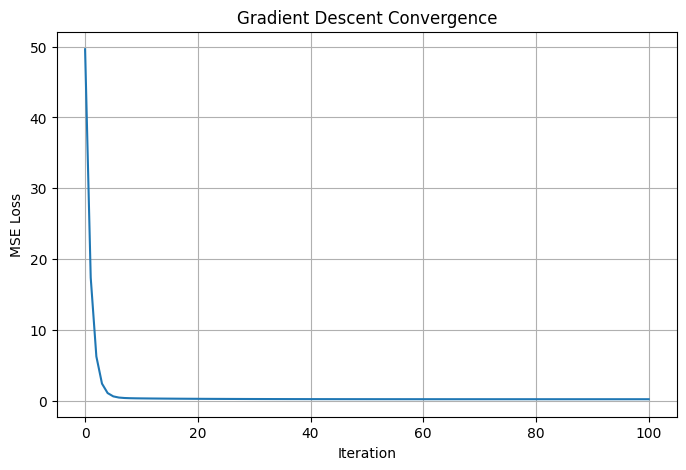

In [3]:

# Plot the optimization path for the loss function

plt.plot(history["loss"])
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence")
plt.show()


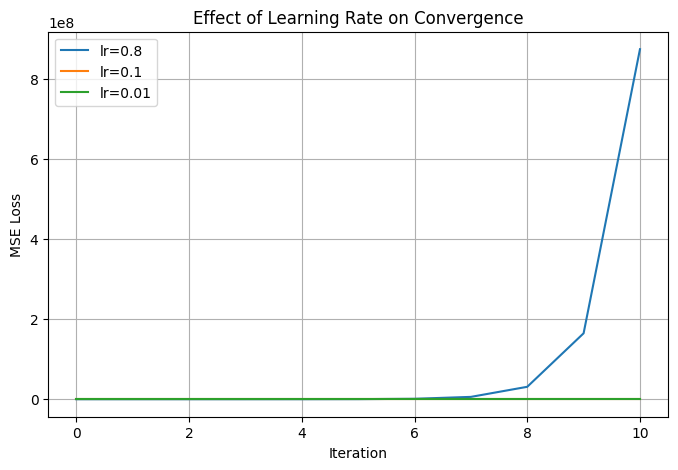

In [4]:

# Compare different learning rates

learning_rates = [0.8, 0.1, 0.01]
results = {}

for lr in learning_rates:
    _, h = gradient_descent(X, y, theta0, learning_rate=lr, n_iterations=10)
    results[lr] = h["loss"]

for lr, loss_curve in results.items():
    plt.plot(loss_curve, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.show()


In [5]:

# Module 1B: Automatic differentiation with TensorFlow

if TF_AVAILABLE:
    x = tf.Variable(3.0)
    y_var = tf.Variable(2.0)

    with tf.GradientTape() as tape:
        f = x + 2 * (y_var ** 2)

    gradients = tape.gradient(f, [x, y_var])
    print("f(x, y) =", f.numpy())
    print("df/dx =", gradients[0].numpy())
    print("df/dy =", gradients[1].numpy())
else:
    print("TensorFlow is not available, so this cell is skipped.")


f(x, y) = 11.0
df/dx = 1.0
df/dy = 8.0



### Hands-on lab
- Change the learning rate and observe whether the optimization becomes slower or diverges.
- Ask students to connect the derivative expression to the actual vector update in code.



## Module 2: The Single-Layer Perceptron and Linear Classification

### Learning objectives
- Implement a threshold-based neuron.
- Train with the perceptron learning rule.
- Compare the classical algorithm with a Keras version.

### Math reminder

The perceptron computes:

$$
\hat{y} = \begin{cases}
1 & \text{if } w^T x + b \ge 0 \\
0 & \text{otherwise}
\end{cases}
$$

and updates weights when it makes a mistake:

$$
w := w + \eta (y - \hat{y}) x, \qquad
b := b + \eta (y - \hat{y}).
$$


In [6]:

# Module 2A: Perceptron from scratch

class PerceptronFromScratch:
    def __init__(self, num_features, lr=0.2):
        self.weights = np.zeros(num_features, dtype=float)
        self.bias = 0.0
        self.lr = lr

    def predict(self, x):
        linear_combination = np.dot(x, self.weights) + self.bias
        return 1 if linear_combination >= 0 else 0

    def fit(self, X, y, epochs=10):
        for epoch in range(epochs):
            errors = 0
            for xi, target in zip(X, y):
                output = self.predict(xi)
                error = target - output
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    errors += 1
            print(f"Epoch {epoch+1:02d} | misclassifications = {errors}")
            if errors == 0:
                break

# Linearly separable dataset: AND gate
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)
y_and = np.array([0, 0, 0, 1])

perceptron = PerceptronFromScratch(num_features=2, lr=0.2)
perceptron.fit(X_and, y_and, epochs=20)

print("Weights:", perceptron.weights)
print("Bias:", perceptron.bias)
print("Predictions:", [perceptron.predict(x) for x in X_and])


Epoch 01 | misclassifications = 2
Epoch 02 | misclassifications = 3
Epoch 03 | misclassifications = 3
Epoch 04 | misclassifications = 0
Weights: [0.4 0.2]
Bias: -0.4000000000000001
Predictions: [0, 0, 0, 1]


In [7]:

# Module 2B: Keras version of a single-neuron classifier

if TF_AVAILABLE:
    model = keras.Sequential([
        layers.Dense(1, activation="sigmoid", input_shape=(2,))
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.2),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(X_and, y_and, epochs=50, verbose=0)
    preds = (model.predict(X_and, verbose=0) > 0.5).astype(int).reshape(-1)

    print("Predictions:", preds.tolist())
    print("Training accuracy:", history.history["accuracy"][-1])
else:
    print("TensorFlow is not available, so this cell is skipped.")


C:\Users\Omid\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predictions: [0, 0, 0, 1]
Training accuracy: 1.0



### Hands-on lab
- Train on AND and OR gates first.
- Compare the learned parameters from the NumPy model with the Keras model.
- Explain why XOR cannot be solved by a single linear separator.



## Module 3: Multi-Layer Perceptrons and Backpropagation

### Learning objectives
- Build a two-layer neural network from scratch.
- Use the XOR problem to motivate hidden layers.
- Connect matrix calculus to automated deep learning frameworks.

### Math reminder

The sigmoid function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

with derivative:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z)).
$$

Backpropagation applies the chain rule to propagate error gradients backward through the network.


In [8]:

# Module 3A: XOR network from scratch with NumPy

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# XOR dataset
X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_train = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

# Weight initialization
np.random.seed(42)
wh = np.random.uniform(size=(2, 2))   # input -> hidden
bh = np.random.uniform(size=(1, 2))
wout = np.random.uniform(size=(2, 1))  # hidden -> output
bout = np.random.uniform(size=(1, 1))
lr = 0.5

loss_history = []

for epoch in range(5000):
    # Forward pass
    hidden_input = X_train @ wh + bh
    hidden_output = sigmoid(hidden_input)

    final_input = hidden_output @ wout + bout
    predicted_output = sigmoid(final_input)

    # Loss
    loss = np.mean((y_train - predicted_output) ** 2)
    loss_history.append(loss)

    # Backward pass
    error = y_train - predicted_output
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    error_hidden_layer = d_predicted_output @ wout.T
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_output)

    # Parameter updates
    wout += hidden_output.T @ d_predicted_output * lr
    bout += np.sum(d_predicted_output, axis=0, keepdims=True) * lr
    wh += X_train.T @ d_hidden_layer * lr
    bh += np.sum(d_hidden_layer, axis=0, keepdims=True) * lr

print("Final predictions:")
print(predicted_output.round(4))


Final predictions:
[[0.0283]
 [0.9752]
 [0.9752]
 [0.0259]]


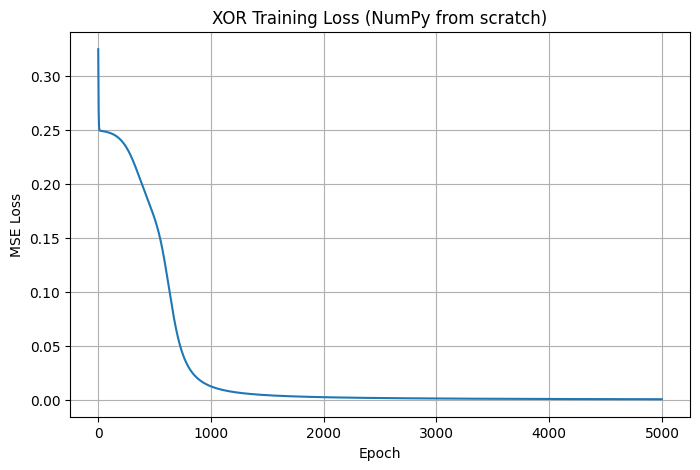

In [9]:

# Plot XOR training loss

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("XOR Training Loss (NumPy from scratch)")
plt.show()


In [10]:

# Evaluate the learned XOR network

hidden_output = sigmoid(X_train @ wh + bh)
predicted_output = sigmoid(hidden_output @ wout + bout)
predicted_classes = (predicted_output > 0.5).astype(int)

print("Predicted probabilities:\n", predicted_output.round(4))
print("Predicted classes:\n", predicted_classes.reshape(-1))
print("True labels:\n", y_train.reshape(-1).astype(int))


Predicted probabilities:
 [[0.0283]
 [0.9753]
 [0.9752]
 [0.0259]]
Predicted classes:
 [0 1 1 0]
True labels:
 [0 1 1 0]


In [11]:

# Module 3B: Keras version of XOR

if TF_AVAILABLE:
    keras_model = keras.Sequential([
        layers.Dense(2, activation="sigmoid", input_shape=(2,)),
        layers.Dense(1, activation="sigmoid")
    ])

    keras_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    keras_history = keras_model.fit(X_train, y_train, epochs=100, verbose=0)
    keras_preds = (keras_model.predict(X_train, verbose=0) > 0.5).astype(int).reshape(-1)

    print("Predicted classes:", keras_preds.tolist())
    print("Final accuracy:", keras_history.history["accuracy"][-1])
else:
    print("TensorFlow is not available, so this cell is skipped.")


Predicted classes: [0, 1, 1, 0]
Final accuracy: 1.0



### Hands-on lab
- Run the NumPy XOR model and the Keras XOR model side by side.
- Ask students to identify which line corresponds to the forward pass and which to the backward pass.
- Discuss how the hidden layer makes XOR solvable.



## Module 4: Scaling Up to Real-World Applications

### Learning objectives
- Train a deeper model on a more realistic binary classification task.
- Use validation data and monitor performance curves.
- See how modern workflows compress the training loop into a few lines.

### What changes here?
- More layers
- Nonlinear activations such as ReLU
- Adam or SGD optimizers
- Validation split and metric tracking


In [12]:

# Module 4: A larger binary classification example

# Synthetic dataset with more structure than a logic gate
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=2,
    class_sep=1.5,
    random_state=42
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)


Training set shape: (1600, 20)
Test set shape: (400, 20)


In [13]:

# Deep network in Keras

if TF_AVAILABLE:
    model = keras.Sequential([
        layers.Dense(16, activation="relu", input_shape=(input_dim,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled, y_train_full,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Test accuracy: {test_acc:.4f}")
else:
    print("TensorFlow is not available, so this cell is skipped.")


C:\Users\Omid\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9725


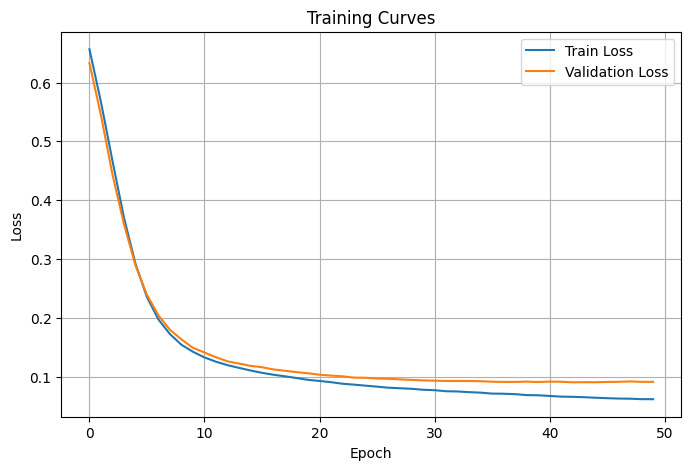

In [14]:

# Plot training and validation loss

if TF_AVAILABLE:
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curves")
    plt.legend()
    plt.show()
else:
    print("TensorFlow is not available, so this cell is skipped.")



## Suggested in-class exercise

Modify the learning rate in the gradient descent and XOR sections, then answer:

- Which values converge fastest?
- Which values diverge?
- How does this connect to the geometry of the loss surface?


## Module 5: Dropout, Underfitting, and Overfitting

### Learning objectives
- See how dropout regularizes neural networks by randomly disabling units during training.
- Compare several dropout rates and observe how the validation score changes.
- Build two models on the same dataset: one that underfits and one that overfits.
- Visualize the difference using learning curves and decision boundaries.

### Key idea
Dropout rate `p` means that a fraction `p` of hidden activations is set to zero during training.
- `p = 0.0`: no dropout, highest capacity, higher risk of overfitting.
- `p = 0.2` to `0.5`: common regularization range.
- `p >= 0.7`: often too aggressive and may cause underfitting.

Dropout rate = 0.0 | validation accuracy = 0.9525 | validation loss = 0.1553
Dropout rate = 0.2 | validation accuracy = 0.9550 | validation loss = 0.1606
Dropout rate = 0.5 | validation accuracy = 0.9575 | validation loss = 0.1619
Dropout rate = 0.7 | validation accuracy = 0.9500 | validation loss = 0.1795


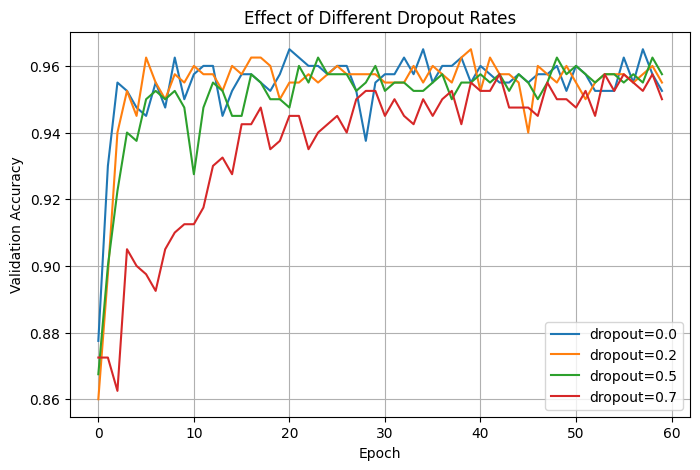

In [15]:
# Module 5A: Dropout regularization demo

if TF_AVAILABLE:
    # A 2D nonlinear dataset so the effect is easy to visualize
    X_drop, y_drop = make_moons(n_samples=2000, noise=0.25, random_state=42)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_drop, y_drop, test_size=0.2, random_state=42, stratify=y_drop
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    def build_dropout_model(dropout_rate):
        return keras.Sequential([
            layers.Input(shape=(2,)),
            layers.Dense(64, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(32, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation='sigmoid'),
        ])

    dropout_rates = [0.0, 0.2, 0.5, 0.7]
    histories = {}
    summary_rows = []

    for rate in dropout_rates:
        model = build_dropout_model(rate)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.01),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=60,
            batch_size=32,
            verbose=0
        )
        histories[rate] = history
        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        summary_rows.append((rate, val_loss, val_acc))
        print(f'Dropout rate = {rate:.1f} | validation accuracy = {val_acc:.4f} | validation loss = {val_loss:.4f}')

    plt.figure()
    for rate, history in histories.items():
        plt.plot(history.history['val_accuracy'], label=f'dropout={rate}')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Effect of Different Dropout Rates')
    plt.legend()
    plt.show()

else:
    print('TensorFlow is not available, so this cell is skipped.')

### Underfitting vs overfitting

In the next example, the same dataset is used twice:
- **Underfitting model:** too small and too constrained, so it cannot learn the structure well.
- **Overfitting model:** too flexible and trained too long, so it memorizes noise and performs worse on validation data.

The first plot shows the decision boundaries. The second plot shows the learning curves.

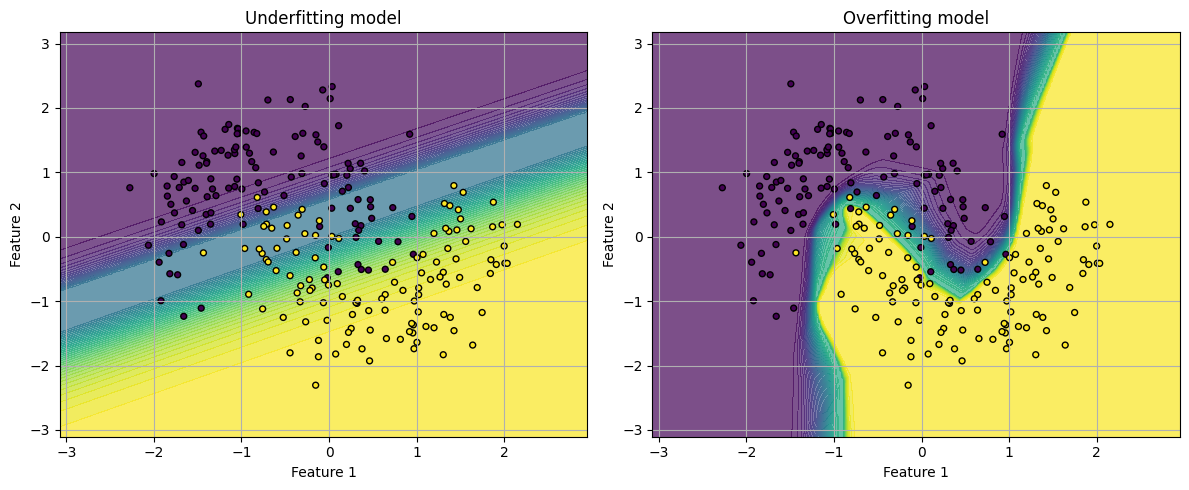

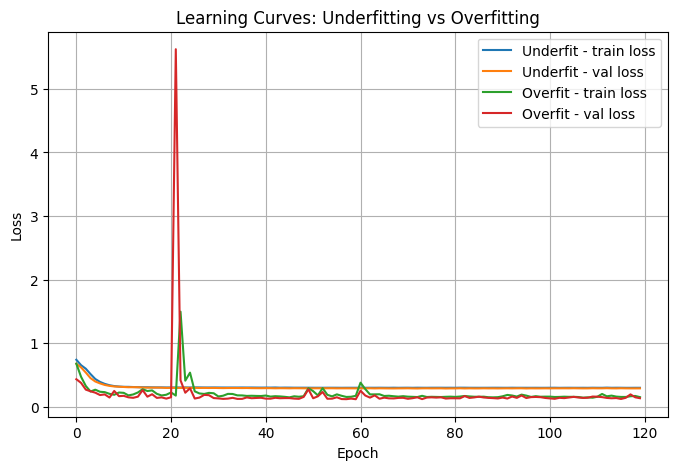

In [16]:
# Module 5B: Underfitting and overfitting on the same dataset

if TF_AVAILABLE:
    X_cmp, y_cmp = make_moons(n_samples=1200, noise=0.28, random_state=7)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_cmp, y_cmp, test_size=0.2, random_state=7, stratify=y_cmp
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=7, stratify=y_train_full
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    def build_underfit_model():
        return keras.Sequential([
            layers.Input(shape=(2,)),
            layers.Dense(2, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])

    def build_overfit_model():
        return keras.Sequential([
            layers.Input(shape=(2,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])

    underfit_model = build_underfit_model()
    overfit_model = build_overfit_model()

    for model in [underfit_model, overfit_model]:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.01),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

    history_underfit = underfit_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=120,
        batch_size=32,
        verbose=0
    )

    history_overfit = overfit_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=120,
        batch_size=32,
        verbose=0
    )

    def plot_decision_boundary(model, X, y, title):
        x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
        y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        grid = np.c_[xx.ravel(), yy.ravel()]
        probs = model.predict(grid, verbose=0).reshape(xx.shape)

        plt.contourf(xx, yy, probs, levels=50, alpha=0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=18)
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plot_decision_boundary(underfit_model, X_val, y_val, 'Underfitting model')
    plt.subplot(1, 2, 2)
    plot_decision_boundary(overfit_model, X_val, y_val, 'Overfitting model')
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(history_underfit.history['loss'], label='Underfit - train loss')
    plt.plot(history_underfit.history['val_loss'], label='Underfit - val loss')
    plt.plot(history_overfit.history['loss'], label='Overfit - train loss')
    plt.plot(history_overfit.history['val_loss'], label='Overfit - val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curves: Underfitting vs Overfitting')
    plt.legend()
    plt.show()
else:
    print('TensorFlow is not available, so this cell is skipped.')
